In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Generate dataset
X, y = make_moons(n_samples=1000, noise=0.2)

# Create DataFrame
df = {
    "X1": X[:, 0],
    "X2": X[:, 1],
    "y": y
}

dataset = pd.DataFrame(df)


print(dataset.head())

         X1        X2  y
0 -0.118880  1.033840  0
1 -0.925647  0.972063  0
2 -0.582447  0.659853  0
3  0.153996  0.243962  1
4  0.522154  1.013265  0


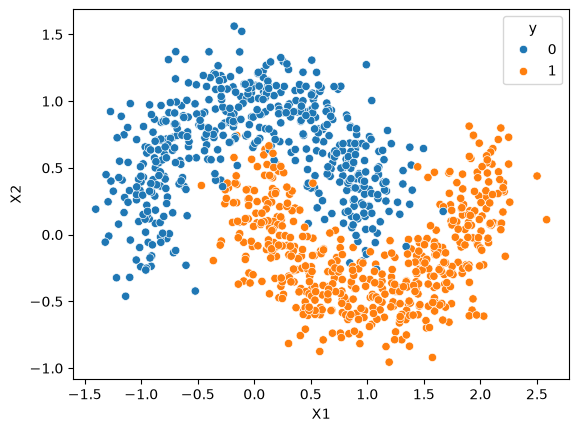

In [2]:
import seaborn as sns

sns.scatterplot(x="X1", y="X2", data=dataset, hue="y")
plt.show()

In [3]:
X_a = dataset.iloc[:,:-1]
Y_a = dataset["y"]

In [4]:
from sklearn.model_selection import train_test_split

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    X_a,
    Y_a,
    test_size=0.2,
    random_state=42
)

# Import models
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Decision Tree model
dt = DecisionTreeClassifier()

# Train model
dt.fit(x_train, y_train)

# Accuracy
train_accuracy = dt.score(x_train, y_train) * 100
test_accuracy = dt.score(x_test, y_test) * 100

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 100.0
Test Accuracy: 98.5


In [5]:
sv= SVC()
sv.fit(x_train, y_train)

# Accuracy
train_accuracy = sv.score(x_train, y_train) * 100
test_accuracy = sv.score(x_test, y_test) * 100
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 96.75
Test Accuracy: 98.0


In [6]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

# Accuracy
train_accuracy = gnb.score(x_train, y_train) * 100
test_accuracy = gnb.score(x_test, y_test) * 100

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 86.625
Test Accuracy: 86.5


In [7]:
from sklearn.ensemble import VotingClassifier

li = [
    ("dt1", DecisionTreeClassifier()),
    ("sv1", SVC()),
    ("gnb1", GaussianNB())
]



In [16]:
vc = VotingClassifier(li)

vc.fit(x_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt1', ...), ('sv1', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[DecisionTreeClassifier(), SVC(), GaussianNB()]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['X1','X2']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [17]:

print(vc.score(x_train, y_train) * 100,vc.score(x_test, y_test) * 100)

97.875 97.5


In [20]:
prd = {"dt":dt.predict(x_test), "svm":sv.predict(x_test), "gnb":gnb.predict(x_test), "vc":vc.predict(x_test)}
pd.DataFrame(prd)

,dt,svm,gnb,vc
0,0,0,0,0
1,1,1,1,1
2,0,0,0,0
3,1,1,1,1
4,1,1,1,1
...,...,...,...,...
195,0,0,0,0
196,0,0,0,0
197,0,0,0,0
198,1,1,0,1


In [ ]:
#for Regrssion you have to do this by yourself okayyy , 
# just take dataset to predcit some value and use models like linear regression and so on
# Then use Voting Regressor process is same just a little changes 
